Disparity is:
Disparity=max(GroupMeans)−min(GroupMeans)
Assume: 0.78−0.45=0.33

This means:
Black voters were predicted to vote Democrat 33 percentage points more often than White voters
This is the disparity.

In [ ]:
import pandas as pd
import numpy as np

bisg_df = pd.read_csv("bisg_done_sample_760193.csv")
pred_df = pd.read_csv("nc_voted_with_predicted_party.csv")

In [ ]:
pred_df = pred_df.rename(columns={"S.No": "S_No"})


In [ ]:
pred_df.columns

Index(['S_No', 'first_name', 'last_name', 'middle_name', 'county_id',
       'county_desc', 'race_code', 'ethnic_code', 'zip_code', 'reason_cd',
       'party_cd', 'gender_code', 'age_at_year_end', 'drivers_lic',
       'birth_state', 'registr_dt', 'strata', 'zcta', 'prob_white',
       'prob_black', 'prob_hisp', 'prob_asian', 'pred_party'],
      dtype='object')

In [ ]:
pred_df["pred_is_dem"] = (pred_df["pred_party"].astype(str).str.upper() == "DEM").astype(int)
pred_df["pred_is_rep"] = (pred_df["pred_party"].astype(str).str.upper() == "REP").astype(int)
pred_df["pred_is_una"] = (pred_df["pred_party"].astype(str).str.upper() == "UNA").astype(int)

In [ ]:
pred_df.columns

Index(['S_No', 'first_name', 'last_name', 'middle_name', 'county_id',
       'county_desc', 'race_code', 'ethnic_code', 'zip_code', 'reason_cd',
       'party_cd', 'gender_code', 'age_at_year_end', 'drivers_lic',
       'birth_state', 'registr_dt', 'strata', 'zcta', 'prob_white',
       'prob_black', 'prob_hisp', 'prob_asian', 'pred_party', 'pred_is_dem',
       'pred_is_rep', 'pred_is_una', 'GT_is_dem', 'GT_is_rep', 'GT_is_una'],
      dtype='object')

In [ ]:
pred_df["GT_is_dem"] = (pred_df["party_cd"].astype(str).str.upper() == "DEM").astype(int)
pred_df["GT_is_rep"] = (pred_df["party_cd"].astype(str).str.upper() == "REP").astype(int)
pred_df["GT_is_una"] = (pred_df["party_cd"].astype(str).str.upper() == "UNA").astype(int)

In [ ]:
def compute_disparity(df, race_col, outcome_col):
    group_means = df.groupby(race_col)[outcome_col].mean()
    disparity = group_means.max() - group_means.min()
    return group_means, disparity


In [ ]:
counts = pred_df.groupby(["party_cd", "race_code"]).size()

# Compute proportions within each party
proportions = counts.groupby(level=0).apply(lambda x: x / x.sum())

for party in proportions.index.get_level_values(0).unique():
    print(f"\nRACE DISTRIBUTION FOR GT PARTY: {party}")
    party_data = proportions[party]  # select this party
    for race, prop in party_data.items():
        print(f"  {race}: {prop:.2%}")



RACE DISTRIBUTION FOR GT PARTY: DEM
  ('DEM', 'A'): 1.66%
  ('DEM', 'B'): 46.61%
  ('DEM', 'HL'): 0.99%
  ('DEM', 'I'): 0.43%
  ('DEM', 'M'): 0.65%
  ('DEM', 'O'): 4.46%
  ('DEM', 'P'): 0.01%
  ('DEM', 'U'): 5.89%
  ('DEM', 'W'): 39.31%

RACE DISTRIBUTION FOR GT PARTY: GRE
  ('GRE', 'A'): 3.47%
  ('GRE', 'B'): 20.79%
  ('GRE', 'HL'): 0.50%
  ('GRE', 'I'): 0.50%
  ('GRE', 'M'): 1.24%
  ('GRE', 'O'): 13.61%
  ('GRE', 'U'): 7.43%
  ('GRE', 'W'): 52.48%

RACE DISTRIBUTION FOR GT PARTY: LIB
  ('LIB', 'A'): 1.24%
  ('LIB', 'B'): 9.80%
  ('LIB', 'HL'): 0.91%
  ('LIB', 'I'): 0.40%
  ('LIB', 'M'): 0.86%
  ('LIB', 'O'): 5.41%
  ('LIB', 'P'): 0.02%
  ('LIB', 'U'): 9.42%
  ('LIB', 'W'): 71.94%

RACE DISTRIBUTION FOR GT PARTY: REP
  ('REP', 'A'): 1.08%
  ('REP', 'B'): 2.04%
  ('REP', 'HL'): 0.34%
  ('REP', 'I'): 0.33%
  ('REP', 'M'): 0.20%
  ('REP', 'O'): 2.54%
  ('REP', 'P'): 0.01%
  ('REP', 'U'): 6.28%
  ('REP', 'W'): 87.17%

RACE DISTRIBUTION FOR GT PARTY: UNA
  ('UNA', 'A'): 2.53%
  ('UNA', 'B

In [ ]:
counts = pred_df.groupby(["pred_party", "race_code"]).size()

# Compute proportions within each party
proportions = counts.groupby(level=0).apply(lambda x: x / x.sum())

for party in proportions.index.get_level_values(0).unique():
    print(f"\nRACE DISTRIBUTION FOR PREDICTED PARTY: {party}")
    party_data = proportions[party]
    for race, prop in party_data.items():
        print(f"  {race}: {prop:.2%}")



RACE DISTRIBUTION FOR PREDICTED PARTY: DEM
  ('DEM', 'A'): 1.74%
  ('DEM', 'B'): 38.62%
  ('DEM', 'HL'): 0.86%
  ('DEM', 'I'): 0.45%
  ('DEM', 'M'): 0.63%
  ('DEM', 'O'): 3.94%
  ('DEM', 'P'): 0.01%
  ('DEM', 'U'): 5.24%
  ('DEM', 'W'): 48.51%

RACE DISTRIBUTION FOR PREDICTED PARTY: REP
  ('REP', 'A'): 0.96%
  ('REP', 'B'): 7.45%
  ('REP', 'HL'): 0.43%
  ('REP', 'I'): 0.34%
  ('REP', 'M'): 0.23%
  ('REP', 'O'): 2.73%
  ('REP', 'P'): 0.01%
  ('REP', 'U'): 6.07%
  ('REP', 'W'): 81.79%

RACE DISTRIBUTION FOR PREDICTED PARTY: UNA
  ('UNA', 'A'): 2.49%
  ('UNA', 'B'): 15.35%
  ('UNA', 'HL'): 1.00%
  ('UNA', 'I'): 0.40%
  ('UNA', 'M'): 0.55%
  ('UNA', 'O'): 5.65%
  ('UNA', 'P'): 0.02%
  ('UNA', 'U'): 13.66%
  ('UNA', 'W'): 60.87%


In [ ]:
parties = ["dem", "rep", "una"]

disparity_dict = {}

for party in parties:
    pred_col = f"pred_is_{party}"
    gt_col = f"GT_is_{party}"

    pred_prop = pred_df[pred_col].mean()  # fraction of predicted rows
    gt_prop = pred_df[gt_col].mean()      # fraction of actual rows

    # Compute disparity as predicted - actual
    disparity_dict[party] = pred_prop - gt_prop

print("PARTY DISPARITY (Predicted - Actual):")
for party, disp in disparity_dict.items():
    print(f"  {party.upper()}: {disp:.2%}")


PARTY DISPARITY (Predicted - Actual):
  DEM: -0.59%
  REP: -1.37%
  UNA: 1.96%


In [ ]:
races = pred_df['race_code'].unique()

disparity_race_dict = {}

for party in parties:
    pred_col = f"pred_is_{party}"
    gt_col = f"GT_is_{party}"
    disparity_race_dict[party] = {}

    for race in races:
        race_rows = pred_df[pred_df['race_code'] == race]

        # Compute predicted and actual proportion within this race
        pred_prop = race_rows[pred_col].mean()
        gt_prop = race_rows[gt_col].mean()

        # Disparity = predicted - actual
        disparity_race_dict[party][race] = pred_prop - gt_prop

for party, race_dict in disparity_race_dict.items():
    print(f"\nDISPARITY FOR PARTY: {party.upper()}")
    for race, disp in race_dict.items():
        if not pd.isna(disp):
            print(f"  {race}: {disp:.2%}")



DISPARITY FOR PARTY: DEM
  U: -2.55%
  W: 4.00%
  B: -13.39%
  O: -4.27%
  A: 0.73%
  HL: -5.67%
  M: -1.83%
  I: 1.29%
  P: 1.94%

DISPARITY FOR PARTY: REP
  U: -1.67%
  W: -4.37%
  B: 7.50%
  O: 0.48%
  A: -2.70%
  HL: 2.37%
  M: 1.14%
  I: -1.09%
  P: -11.65%

DISPARITY FOR PARTY: UNA
  U: 4.22%
  W: 0.37%
  B: 5.89%
  O: 3.79%
  A: 1.97%
  HL: 3.30%
  M: 0.69%
  I: -0.20%
  P: 9.71%


In [ ]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

disp_df = pd.DataFrame(disparity_race_dict)
disp_df = disp_df.dropna()
disp_df = disp_df.sort_index()

print(disp_df)


         dem       rep       una
A   0.007290 -0.027003  0.019713
B  -0.133867  0.074995  0.058872
HL -0.056704  0.023740  0.032963
I   0.012947 -0.010903 -0.002044
M  -0.018338  0.011392  0.006946
O  -0.042698  0.004786  0.037912
P   0.019417 -0.116505  0.097087
U  -0.025539 -0.016662  0.042202
W   0.040001 -0.043734  0.003733


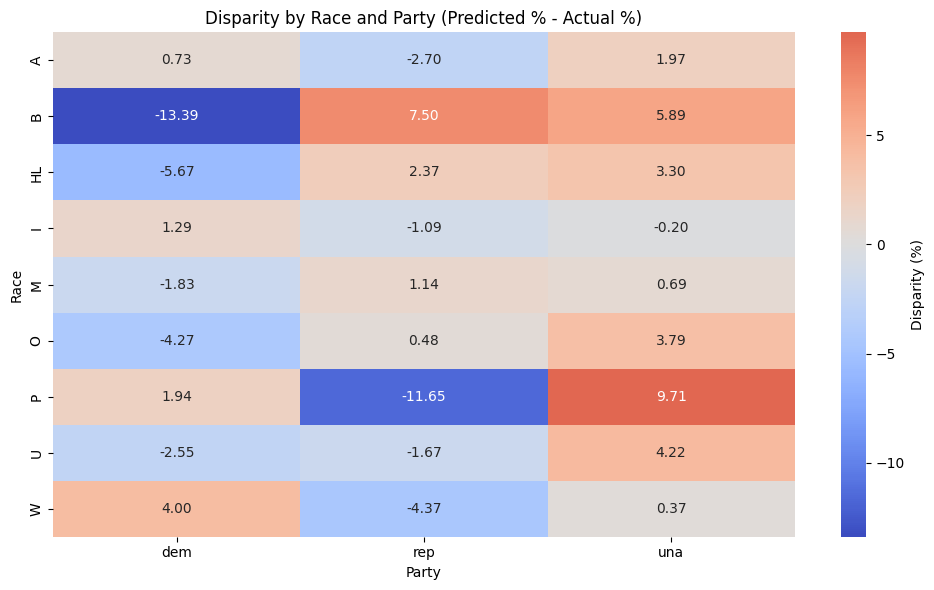

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    disp_df * 100,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar_kws={'label': 'Disparity (%)'}
)

plt.title("Disparity by Race and Party (Predicted % - Actual %)")
plt.xlabel("Party")
plt.ylabel("Race")
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

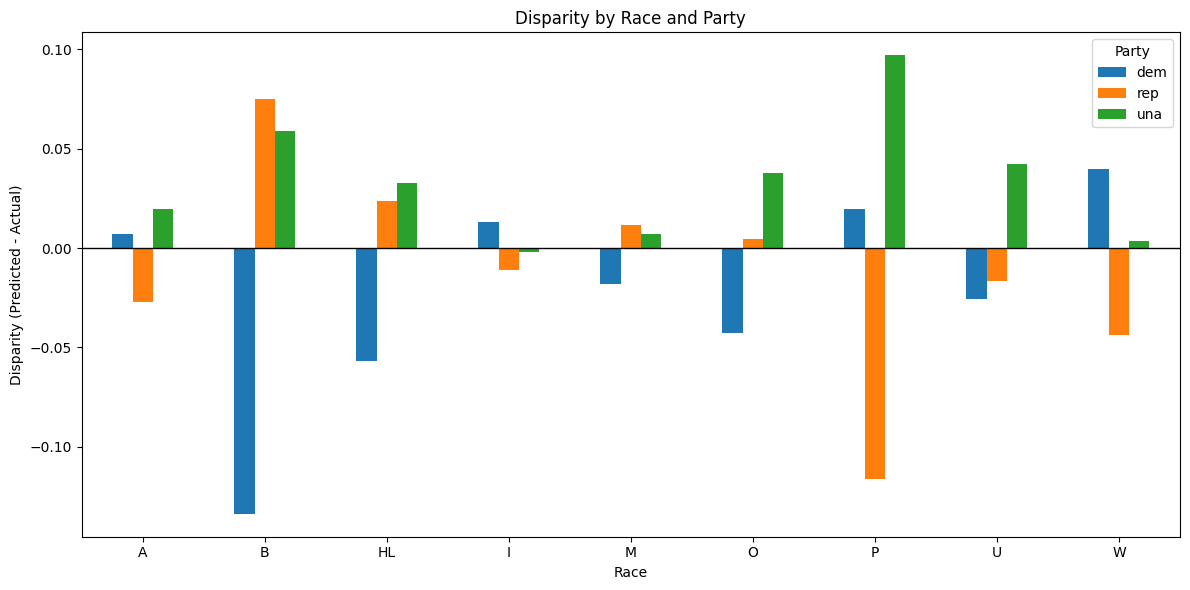

In [ ]:
plt.figure(figsize=(12, 6))
disp_df.plot(kind="bar", figsize=(12,6))

plt.axhline(0, color='black', linewidth=1)
plt.title("Disparity by Race and Party")
plt.ylabel("Disparity (Predicted - Actual)")
plt.xlabel("Race")
plt.xticks(rotation=0)
plt.legend(title="Party")
plt.tight_layout()
plt.show()


# Weighing

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pred_df.copy() #keeping original unaffected

bisg_cols = ["prob_white", "prob_black", "prob_hisp", "prob_asian"]
race_labels = ["white", "black", "hisp", "asian"]
parties = ["dem", "rep", "una"]

In [ ]:
# Normalize BISG probabilities (soft weights)
bisg_probs = df[bisg_cols].fillna(0).astype(float)

row_sum = bisg_probs.sum(axis=1)
row_sum[row_sum == 0] = 1.0   # avoid divide by zero

bisg_probs = bisg_probs.div(row_sum, axis=0)

In [ ]:
'''To compute disparity (predicted - actual party proportion) for a race:
1. Multiply each person's party indicator (predicted or actual) by their probability of belonging to that race
2. Sum these weighted contributions and divide by the total probability mass for the race'''

# SOFT DISPARITY (weighted by probability)
soft_disparity = pd.DataFrame(index=race_labels, columns=parties, dtype=float)

for race_idx, race_col in enumerate(bisg_cols):
    R = race_labels[race_idx]
    w = bisg_probs[race_col].values
    denom = w.sum()

    if denom == 0:
        soft_disparity.loc[R] = np.nan
        continue

    for party in parties:
        pred_is = df[f"pred_is_{party}"].values
        gt_is   = df[f"GT_is_{party}"].values

        pred_prop = (w * pred_is).sum() / denom
        gt_prop   = (w * gt_is).sum() / denom

        soft_disparity.loc[R, party] = pred_prop - gt_prop

**Step 1:**
w = bisg_probs[race_col].values

these are the P(A|Z) values — the BISG probabilities

**Step 2:**
w * pred_is

this is P(A|Z) × predicted_party_indicator

Exactly what the paper does: weight each Y by race probability.

**Step 3:**
(w * pred_is).sum() / denom
→ this is:

∑𝑃(𝐴∣𝑍𝑖)*𝑌𝑖
/
∑𝑃(𝐴∣𝑍𝑖)

**Step 4:**

Compute:
predicted proportion for party - ground truth proportion for party
predicted proportion for party-ground truth proportion for party

That is the disparity.

In [ ]:
'''Just take the max probability among the race probability values'''
# HARD DISPARITY (argmax race)
argmax_race = bisg_probs.idxmax(axis=1)

# Map columns to simple race labels
col_to_label = dict(zip(bisg_cols, race_labels))
argmax_race = argmax_race.map(col_to_label)

hard_disparity = pd.DataFrame(index=race_labels, columns=parties, dtype=float)

for R in race_labels:
    group = df[argmax_race == R]
    if len(group) == 0:
        hard_disparity.loc[R] = np.nan
        continue

    for party in parties:
        pred_prop = group["pred_party"].str.lower().eq(party).mean()
        gt_prop   = group["party_cd"].str.lower().eq(party).mean()

        hard_disparity.loc[R, party] = pred_prop - gt_prop



In [ ]:
print("\nSOFT (Weighted) Race-Party Disparity (%)")
print((soft_disparity * 100).round(2))

print("\nHARD (Argmax Race) Disparity (%)")
print((hard_disparity * 100).round(2))



SOFT (Weighted) Race-Party Disparity (%)
        dem   rep   una
white  1.62 -2.75  1.13
black -4.82  1.47  3.36
hisp  -3.44  0.30  3.14
asian  0.11 -2.09  1.99

HARD (Argmax Race) Disparity (%)
        dem   rep   una
white  1.10 -2.49  1.39
black -6.78  2.80  3.99
hisp  -3.86  0.54  3.32
asian -0.02 -1.95  1.98


In [ ]:
soft_pct = soft_disparity * 100
hard_pct = hard_disparity * 100

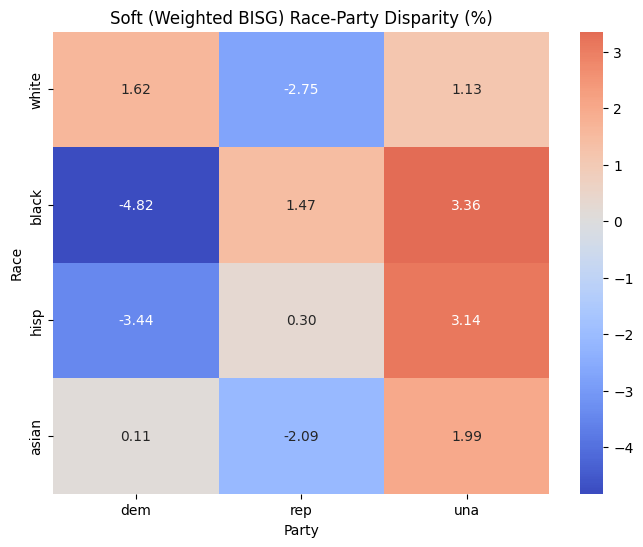

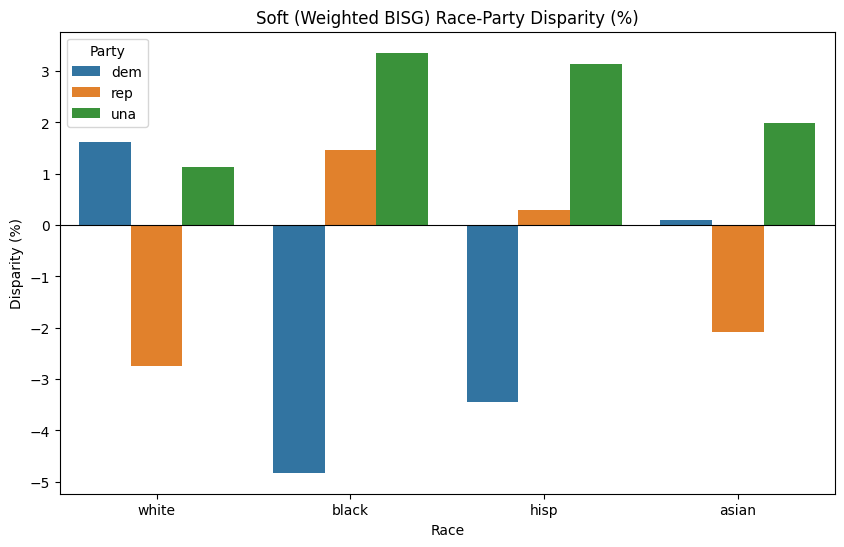

In [ ]:
#Plots for Soft Disparity
plt.figure(figsize=(8,6))
sns.heatmap(soft_pct, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Soft (Weighted BISG) Race-Party Disparity (%)")
plt.ylabel("Race")
plt.xlabel("Party")
plt.show()

soft_pct_reset = soft_pct.reset_index().melt(id_vars="index", var_name="Party", value_name="Disparity")
soft_pct_reset.rename(columns={"index":"Race"}, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(data=soft_pct_reset, x="Race", y="Disparity", hue="Party")
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Soft (Weighted BISG) Race-Party Disparity (%)")
plt.ylabel("Disparity (%)")
plt.show()


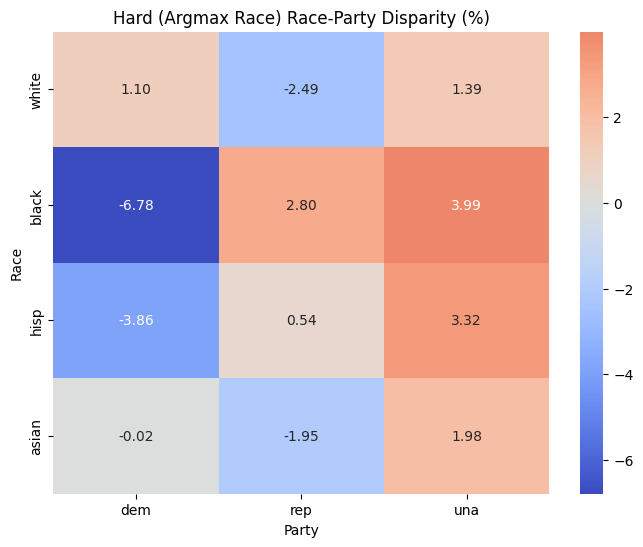

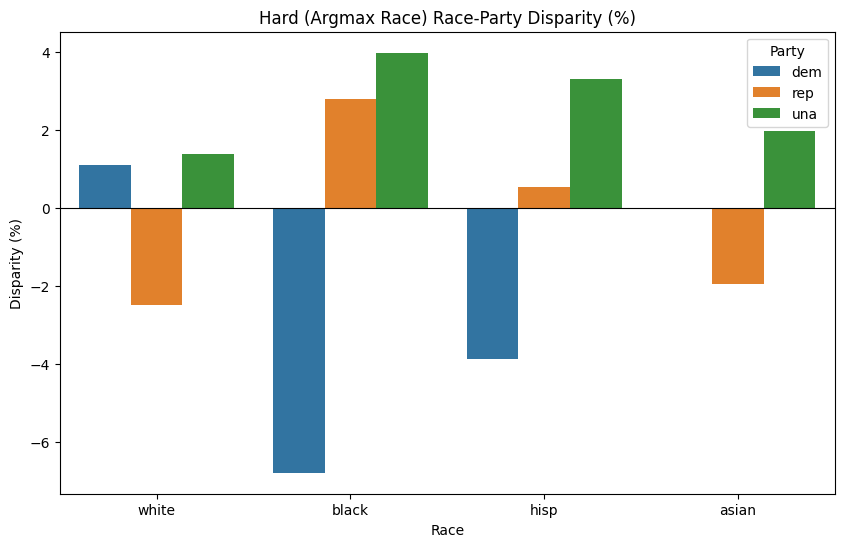

In [ ]:
#Plots for Hard Disparity
plt.figure(figsize=(8,6))
sns.heatmap(hard_pct, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Hard (Argmax Race) Race-Party Disparity (%)")
plt.ylabel("Race")
plt.xlabel("Party")
plt.show()



hard_pct_reset = hard_pct.reset_index().melt(id_vars="index", var_name="Party", value_name="Disparity")
hard_pct_reset.rename(columns={"index":"Race"}, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(data=hard_pct_reset, x="Race", y="Disparity", hue="Party")
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Hard (Argmax Race) Race-Party Disparity (%)")
plt.ylabel("Disparity (%)")
plt.show()
